<a href="https://colab.research.google.com/github/rawben789/Neural-Network-encouraging-smoothening/blob/main/Final_Smoothening_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training on 40 points
Loss Weights: Data=1.0, Physics=1.0, Boundary=1.0, Smoothness=0.01
Epoch 0000 | Total: 2.86484 | Data: 0.46075 | Physics: 0.05119 | Boundary: 2.35287 | Smooth: 0.00420
Epoch 0500 | Total: 0.03907 | Data: 0.03282 | Physics: 0.00110 | Boundary: 0.00040 | Smooth: 0.47544
Epoch 1000 | Total: 0.03958 | Data: 0.03203 | Physics: 0.00172 | Boundary: 0.00108 | Smooth: 0.47413
Epoch 1500 | Total: 0.03903 | Data: 0.03269 | Physics: 0.00115 | Boundary: 0.00044 | Smooth: 0.47511
Epoch 2000 | Total: 0.03903 | Data: 0.03271 | Physics: 0.00113 | Boundary: 0.00043 | Smooth: 0.47516
Epoch 2500 | Total: 0.03902 | Data: 0.03271 | Physics: 0.00113 | Boundary: 0.00043 | Smooth: 0.47514

Plot saved to smoothing_result.png


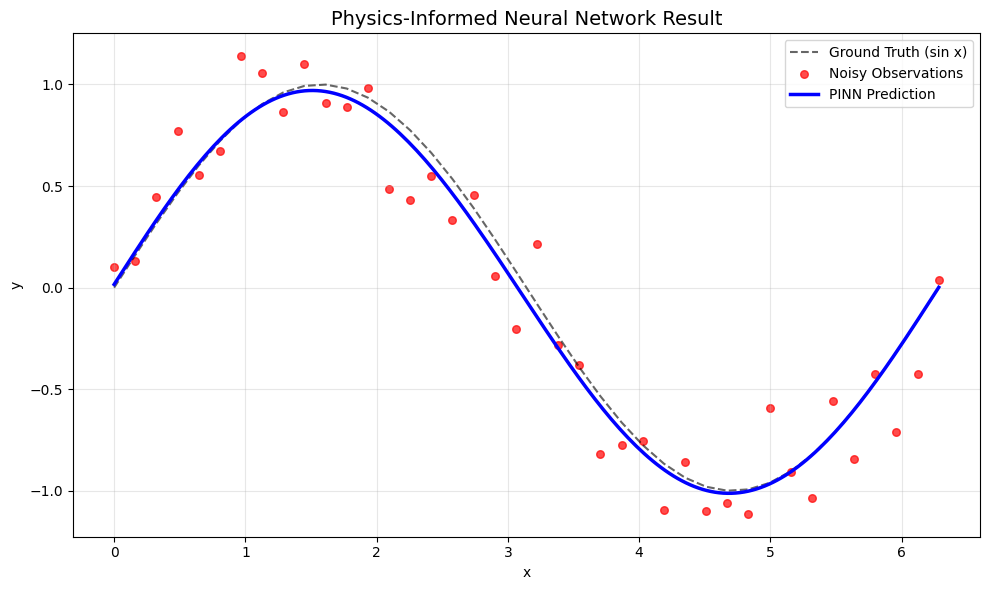

In [ ]:
# Implementing Custom Loss Function with Physics-Informed Components
# Obj: 1. Fitting the noisy training data (DATA LOSS)
#      2. Enforcing physics constraints (PHYSICS LOSS)
#      3. Satisfying initial conditions (INITIAL LOSS)
#      4. Encouraging smooth predictions (SMOOTHNESS LOSS)

# Data Generation
# Generate a noisy dataset from the ground truth function y = sin(x) on the domain x ∈ [0,2π].
# Generate N = 40 training points uniformly distributed in [0,2π].
# Add Gaussian noise: y_noisy = sin(x) + ϵ where ϵ ∼ N(0,0.2).

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. CONFIGURATION
class Config:
    N_SAMPLES = 40
    NOISE_STD = 0.2
    EPOCHS = 3000
    LR = 0.01
    # Lambda weights control the trade-off between different objectives:
    DATA_WEIGHT = 1.0          # How much to fit the noisy data
    PHYSICS_WEIGHT = 1.0       # How much to enforce physics (d²y/dx² + y = 0)
    BOUNDARY_WEIGHT = 1.0      # How much to enforce boundary conditions (at x=0 and x=2π)
    SMOOTHNESS_WEIGHT = 0.01   # How much to penalize curvature (smoothness)

# 2. DATA GENERATION
def generate_data():
    """Generates noisy sin(x) data as described in the challenge."""
    X = np.linspace(0, 2 * np.pi, Config.N_SAMPLES)
    y_true = np.sin(X)
    noise = np.random.normal(0, Config.NOISE_STD, size=X.shape)
    y_noisy = y_true + noise

    # Convert to PyTorch tensors (N, 1)
    X_tensor = torch.tensor(X, dtype=torch.float32).view(-1, 1)
    y_tensor = torch.tensor(y_noisy, dtype=torch.float32).view(-1, 1)
    return X_tensor, y_tensor, X, y_true

# 3. MODEL
class SmoothNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Standard MLP: 1 -> 64 -> 64 -> 1
        # Tanh activation is crucial for calculating higher-order derivatives
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# 4. CUSTOM LOSS WITH ALL FOUR COMPONENTS
def physics_informed_loss(model, x_input, y_target, lambda_data, lambda_physics,
                         lambda_boundary, lambda_smooth):
    """
    Physics-Informed Loss Function with 4 components:

    1. DATA LOSS - Fits the model to noisy observations
    2. PHYSICS LOSS - Enforces the differential equation d²y/dx² + y = 0
    3. BOUNDARY LOSS - Enforces boundary conditions at x=0 AND x=2π
    4. SMOOTHNESS LOSS - Penalizes excessive curvature
    """
    # Enable gradient computation for x_input (needed for derivatives)
    x_input.requires_grad = True
    y_pred = model(x_input)

    # COMPONENT 1: DATA LOSS
    # Standard Mean Squared Error between predictions and noisy data
    # This ensures the model fits the training points
    data_loss = nn.MSELoss()(y_pred, y_target)

    # COMPONENT 2 & 4: PHYSICS LOSS + SMOOTHNESS LOSS
    # Both require computing derivatives of the neural network output

    # First derivative: dy/dx (slope of the curve)
    # torch.autograd.grad computes gradients automatically
    grads = torch.autograd.grad(
        y_pred, x_input,
        grad_outputs=torch.ones_like(y_pred),  # Needed for vector output
        create_graph=True  # Keep computation graph for second derivative
    )[0]

    # Second derivative: d²y/dx² (curvature of the curve)
    # We take the derivative of the first derivative
    grad_2 = torch.autograd.grad(
        grads, x_input,
        grad_outputs=torch.ones_like(grads),
        create_graph=True  # Keep graph for backpropagation
    )[0]

    # PHYSICS LOSS: For y = sin(x), we know d²y/dx² = -sin(x) = -y
    # Therefore: d²y/dx² + y = 0 (this is the physics constraint)
    # We minimize the squared residual of this equation
    physics_residual = grad_2 + y_pred
    physics_loss = torch.mean(physics_residual ** 2)

    # SMOOTHNESS LOSS: Penalize large second derivatives (curvature)
    # This prevents the curve from wiggling too much to fit noise
    smoothness_penalty = torch.mean(grad_2 ** 2)

    # COMPONENT 3: BOUNDARY LOSS (Edge Loss at both endpoints)
    # For y = sin(x) on [0, 2π], we know the boundary conditions:
    # At x=0:  y(0) = sin(0) = 0,  dy/dx(0) = cos(0) = 1
    # At x=2π: y(2π) = sin(2π) = 0, dy/dx(2π) = cos(2π) = 1
    # We enforce these at BOTH edges for better curve fitting

    # --- Boundary at x = 0 (Initial condition) ---
    x_zero = torch.zeros(1, 1, requires_grad=True)
    y_at_zero = model(x_zero)

    # Calculate the derivative at x = 0
    dy_dx_at_zero = torch.autograd.grad(
        y_at_zero, x_zero,
        grad_outputs=torch.ones_like(y_at_zero),
        create_graph=True
    )[0]

    # Penalize deviation from initial conditions
    bc_loss_y0 = (y_at_zero - 0.0) ** 2      # y(0) should be 0
    bc_loss_dy0 = (dy_dx_at_zero - 1.0) ** 2  # dy/dx(0) should be 1

    # --- Boundary at x = 2π (Final condition) ---
    x_final = torch.tensor([[2 * np.pi]], dtype=torch.float32, requires_grad=True)
    y_at_final = model(x_final)

    # Calculate the derivative at x = 2π
    dy_dx_at_final = torch.autograd.grad(
        y_at_final, x_final,
        grad_outputs=torch.ones_like(y_at_final),
        create_graph=True
    )[0]

    # Penalize deviation from final conditions
    bc_loss_y_final = (y_at_final - 0.0) ** 2      # y(2π) should be 0
    bc_loss_dy_final = (dy_dx_at_final - 1.0) ** 2  # dy/dx(2π) should be 1

    # Total boundary loss (sum of both edges)
    boundary_loss = bc_loss_y0 + bc_loss_dy0 + bc_loss_y_final + bc_loss_dy_final

    # TOTAL LOSS: Weighted combination of all components
    # Each component is multiplied by its weight (lambda)
    # This allows us to control the importance of each objective
    total_loss = (
        lambda_data * data_loss +           # Fit the data
        lambda_physics * physics_loss +     # Obey physics
        lambda_boundary * boundary_loss +   # Satisfy boundary conditions (both edges)
        lambda_smooth * smoothness_penalty  # Stay smooth
    )

    # Return total loss and individual components for monitoring
    return total_loss, data_loss.item(), physics_loss.item(), boundary_loss.item(), smoothness_penalty.item()

# 5. TRAINING
def train():
    X_train, y_train, X_np, y_true_np = generate_data()

    model = SmoothNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LR)

    print(f"\nTraining on {Config.N_SAMPLES} points")
    print(f"Loss Weights: Data={Config.DATA_WEIGHT}, Physics={Config.PHYSICS_WEIGHT}, "
          f"Boundary={Config.BOUNDARY_WEIGHT}, Smoothness={Config.SMOOTHNESS_WEIGHT}")

    for epoch in range(Config.EPOCHS):
        optimizer.zero_grad()

        # Calculate physics-informed loss with all 4 components
        loss, data, physics, boundary, smoothness = physics_informed_loss(
            model, X_train, y_train,
            Config.DATA_WEIGHT,
            Config.PHYSICS_WEIGHT,
            Config.BOUNDARY_WEIGHT,
            Config.SMOOTHNESS_WEIGHT
        )

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Total: {loss.item():.5f} | "
                  f"Data: {data:.5f} | Physics: {physics:.5f} | "
                  f"Boundary: {boundary:.5f} | Smooth: {smoothness:.5f}")

    return model, X_train, y_train, X_np, y_true_np

# 6. VISUALIZATION
def visualize_results(model, X_train, y_train, X_raw, y_true_raw):
    # Create a dense grid for plotting the learned curve
    X_dense = torch.linspace(0, 2*np.pi, 200).view(-1, 1)
    with torch.no_grad():
        y_pred = model(X_dense).numpy()

    X_dense_np = X_dense.numpy()

    plt.figure(figsize=(10, 6))

    # 1. The Ground Truth
    plt.plot(X_raw, y_true_raw, 'k--', label='Ground Truth (sin x)', alpha=0.6)

    # 2. The Noisy Training Data
    plt.scatter(X_train.detach().numpy(), y_train.detach().numpy(),
                color='red', s=30, alpha=0.7, label='Noisy Observations')

    # 3. The Model Prediction
    plt.plot(X_dense_np, y_pred, 'b-', linewidth=2.5, label='PINN Prediction')
    plt.title('Physics-Informed Neural Network Result', fontsize=14)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    filename = "smoothing_result.png"
    plt.savefig(filename, dpi=150)
    print(f"\nPlot saved to {filename}")
    plt.show()

if __name__ == "__main__":
    model, X_t, y_t, X_r, y_r = train()
    visualize_results(model, X_t, y_t, X_r, y_r)

**With L-BFGS Optimizer**


Training on 40 points using L-BFGS
Loss Weights: Data=1.0, Physics=10, Boundary=100.0, Smoothness=0.01
Epoch 0000 | Total: 0.34998 | Data: 0.27071 | Physics: 0.00788 | Boundary: 1.20691 | Smooth: 0.04849
Epoch 0010 | Total: 0.04735 | Data: 0.03373 | Physics: 0.00089 | Boundary: 0.00543 | Smooth: 0.47095
Epoch 0020 | Total: 0.04068 | Data: 0.03423 | Physics: 0.00016 | Boundary: 0.00533 | Smooth: 0.47947
Epoch 0030 | Total: 0.04021 | Data: 0.03423 | Physics: 0.00012 | Boundary: 0.00571 | Smooth: 0.47692
Epoch 0040 | Total: 0.04021 | Data: 0.03423 | Physics: 0.00012 | Boundary: 0.00571 | Smooth: 0.47692
Epoch 0050 | Total: 0.04021 | Data: 0.03423 | Physics: 0.00012 | Boundary: 0.00571 | Smooth: 0.47692
Epoch 0060 | Total: 0.04021 | Data: 0.03423 | Physics: 0.00012 | Boundary: 0.00571 | Smooth: 0.47692
Epoch 0070 | Total: 0.04021 | Data: 0.03423 | Physics: 0.00012 | Boundary: 0.00571 | Smooth: 0.47692
Epoch 0080 | Total: 0.04021 | Data: 0.03423 | Physics: 0.00012 | Boundary: 0.00571 | Smo

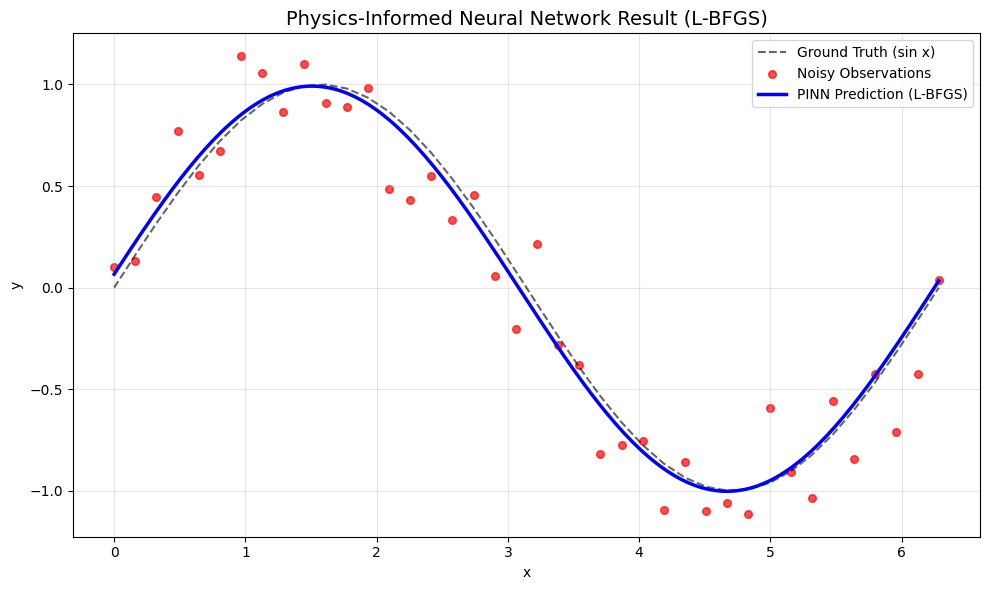

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. CONFIGURATION
class Config:
    N_SAMPLES = 40
    NOISE_STD = 0.2

    # CHANGED: L-BFGS converges much faster but is heavier per step.
    # Reduced epochs from 3000 -> 200 (usually sufficient for L-BFGS).
    EPOCHS = 200

    # CHANGED: L-BFGS works best with LR=1.0 (Adam uses 0.01)
    LR = 1.0

    # Lambda weights (Same as before)
    DATA_WEIGHT = 1.0
    PHYSICS_WEIGHT = 10
    BOUNDARY_WEIGHT = 100.0
    SMOOTHNESS_WEIGHT = 0.01

# 2. DATA GENERATION
def generate_data():
    """Generates noisy sin(x) data as described in the challenge."""
    X = np.linspace(0, 2 * np.pi, Config.N_SAMPLES)
    y_true = np.sin(X)
    noise = np.random.normal(0, Config.NOISE_STD, size=X.shape)
    y_noisy = y_true + noise

    # Convert to PyTorch tensors (N, 1)
    X_tensor = torch.tensor(X, dtype=torch.float32).view(-1, 1)
    y_tensor = torch.tensor(y_noisy, dtype=torch.float32).view(-1, 1)
    return X_tensor, y_tensor, X, y_true

# 3. MODEL
class SmoothNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Standard MLP: 1 -> 64 -> 64 -> 1
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# 4. CUSTOM LOSS WITH ALL FOUR COMPONENTS
def physics_informed_loss(model, x_input, y_target, lambda_data, lambda_physics,
                          lambda_boundary, lambda_smooth):
    x_input.requires_grad = True
    y_pred = model(x_input)

    # 1. DATA LOSS
    data_loss = nn.MSELoss()(y_pred, y_target)

    # 2. PHYSICS & SMOOTHNESS
    grads = torch.autograd.grad(
        y_pred, x_input,
        grad_outputs=torch.ones_like(y_pred),
        create_graph=True
    )[0]

    grad_2 = torch.autograd.grad(
        grads, x_input,
        grad_outputs=torch.ones_like(grads),
        create_graph=True
    )[0]

    physics_residual = grad_2 + y_pred
    physics_loss = torch.mean(physics_residual ** 2)
    smoothness_penalty = torch.mean(grad_2 ** 2)

    # 3. BOUNDARY LOSS
    # Boundary at x = 0
    x_zero = torch.zeros(1, 1, requires_grad=True)
    y_at_zero = model(x_zero)
    dy_dx_at_zero = torch.autograd.grad(
        y_at_zero, x_zero, grad_outputs=torch.ones_like(y_at_zero), create_graph=True
    )[0]
    bc_loss_y0 = (y_at_zero - 0.0) ** 2
    bc_loss_dy0 = (dy_dx_at_zero - 1.0) ** 2

    # Boundary at x = 2π
    x_final = torch.tensor([[2 * np.pi]], dtype=torch.float32, requires_grad=True)
    y_at_final = model(x_final)
    dy_dx_at_final = torch.autograd.grad(
        y_at_final, x_final, grad_outputs=torch.ones_like(y_at_final), create_graph=True
    )[0]
    bc_loss_y_final = (y_at_final - 0.0) ** 2
    bc_loss_dy_final = (dy_dx_at_final - 1.0) ** 2

    boundary_loss = bc_loss_y0 + bc_loss_dy0 + bc_loss_y_final + bc_loss_dy_final

    # TOTAL LOSS
    total_loss = (
        lambda_data * data_loss +
        lambda_physics * physics_loss +
        lambda_boundary * 0 +
        lambda_smooth * smoothness_penalty
    )

    return total_loss, data_loss.item(), physics_loss.item(), boundary_loss.item(), smoothness_penalty.item()

# 5. TRAINING (MODIFIED FOR L-BFGS)
def train():
    X_train, y_train, X_np, y_true_np = generate_data()
    model = SmoothNet()

    # CHANGED: Use LBFGS optimizer
    # 'strong_wolfe' line search is critical for PINN stability
    optimizer = torch.optim.LBFGS(model.parameters(), lr=Config.LR,
                                  history_size=10,
                                  line_search_fn="strong_wolfe")

    print(f"\nTraining on {Config.N_SAMPLES} points using L-BFGS")
    print(f"Loss Weights: Data={Config.DATA_WEIGHT}, Physics={Config.PHYSICS_WEIGHT}, "
          f"Boundary={Config.BOUNDARY_WEIGHT}, Smoothness={Config.SMOOTHNESS_WEIGHT}")

    # Variables to store loss history for printing
    history = {'total': [], 'data': [], 'phys': [], 'bound': [], 'smooth': []}

    for epoch in range(Config.EPOCHS):

        # CHANGED: L-BFGS requires a closure function
        def closure():
            optimizer.zero_grad()
            loss, data, physics, boundary, smoothness = physics_informed_loss(
                model, X_train, y_train,
                Config.DATA_WEIGHT, Config.PHYSICS_WEIGHT,
                Config.BOUNDARY_WEIGHT, Config.SMOOTHNESS_WEIGHT
            )
            loss.backward()

            # Save values for printing
            history['total'] = loss.item()
            history['data'] = data
            history['phys'] = physics
            history['bound'] = boundary
            history['smooth'] = smoothness
            return loss

        # Perform the optimization step
        optimizer.step(closure)

        if epoch % 10 == 0:  # Print more frequently as epochs are fewer
            print(f"Epoch {epoch:04d} | Total: {history['total']:.5f} | "
                  f"Data: {history['data']:.5f} | Physics: {history['phys']:.5f} | "
                  f"Boundary: {history['bound']:.5f} | Smooth: {history['smooth']:.5f}")

    return model, X_train, y_train, X_np, y_true_np

# 6. VISUALIZATION
def visualize_results(model, X_train, y_train, X_raw, y_true_raw):
    X_dense = torch.linspace(0, 2*np.pi, 200).view(-1, 1)
    with torch.no_grad():
        y_pred = model(X_dense).numpy()

    X_dense_np = X_dense.numpy()

    plt.figure(figsize=(10, 6))
    plt.plot(X_raw, y_true_raw, 'k--', label='Ground Truth (sin x)', alpha=0.6)
    plt.scatter(X_train.detach().numpy(), y_train.detach().numpy(),
                color='red', s=30, alpha=0.7, label='Noisy Observations')
    plt.plot(X_dense_np, y_pred, 'b-', linewidth=2.5, label='PINN Prediction (L-BFGS)')
    plt.title('Physics-Informed Neural Network Result (L-BFGS)', fontsize=14)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    filename = "smoothing_result_lbfgs.png"
    plt.savefig(filename, dpi=150)
    print(f"\nPlot saved to {filename}")
    plt.show()

if __name__ == "__main__":
    model, X_t, y_t, X_r, y_r = train()
    visualize_results(model, X_t, y_t, X_r, y_r)

**Lets do it with SciANN's**

In [1]:
# 1. INSTALLATION
# SciANN requires TensorFlow as a backend.
!pip install sciann tensorflow

import numpy as np
import matplotlib.pyplot as plt
import sciann as sn

# 2. DATA GENERATION
# We create 40 points of a sine wave and add random Gaussian noise.
np.random.seed(42)
n_samples = 40
x_data = np.linspace(0, 2*np.pi, n_samples).reshape(-1, 1)
y_true = np.sin(x_data)
y_noisy = y_true + 0.2 * np.random.normal(size=x_data.shape)

# 3. NETWORK ARCHITECTURE SETUP
# Variable 'x' is our input. It's symbolic, acting as a placeholder for data.
x = sn.Variable('x')

# Functional 'y' is our Neural Network (MLP).
# [64, 64] means 2 hidden layers with 64 neurons each.
# 'tanh' is used because it has non-zero derivatives (required for smoothing).
y = sn.Functional('y', x, [64, 64], activation='tanh')

# 4. DEFINING THE PHYSICS/CONSTRAINTS
# Constraint A: Data Fitting (MSE loss between network output and noisy data)
c1 = sn.Data(y)

# Constraint B: Smoothness (Reinforced Smoothing)
# We calculate the 2nd derivative of y with respect to x (curvature).
# sn.math.diff(y, x, order=2) is the SciANN way of doing d^2y/dx^2.
d2y_dx2 = sn.math.diff(y, x, order=2)

# sn.Tie forces the 2nd derivative to be a specific value (0.0 in this case).
# This penalizes "wiggles" in the curve.
c2 = sn.Tie(d2y_dx2, 0.0)

# 5. MODEL COMPILATION
# SciModel combines the inputs and constraints.
# loss_weights: 1.0 for data fitting, 0.01 for the smoothness penalty.
model = sn.SciModel(
    inputs=x,
    targets=[c1, c2],
    loss_weights=[1.0, 0.01],
    optimizer='adam'
)

# 6. TRAINING
# 'y_noisy' maps to c1 (Data).
# 'zero' is a SciANN keyword that maps to c2 (Tie to 0.0).
history = model.train(
    x_data,
    [y_noisy, 'zero'],
    epochs=2000,
    batch_size=n_samples,
    verbose=0
)

# 7. PREDICTION & VISUALIZATION
x_test = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_pred = y.eval(model, x_test)

plt.figure(figsize=(10, 5))
plt.scatter(x_data, y_noisy, color='red', label='Noisy Data', alpha=0.5)
plt.plot(x_test, np.sin(x_test), 'k--', label='True Sine')
plt.plot(x_test, y_pred, 'b-', linewidth=3, label='SciANN Fit')
plt.legend()
plt.title("Curve Fitting with Reinforced Smoothing (SciANN)")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 18.2 MB/s eta 0:00:00


AttributeError: module 'keras.backend' has no attribute 'get_graph'

In [2]:
# 1. FIX THE VERSION ERROR
!pip uninstall -y tensorflow keras
!pip install tensorflow==2.15.0 sciann
# IMPORTANT: After this finishes, go to Runtime -> Restart Session

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.10.0
Uninstalling keras-3.10.0:
  Successfully uninstalled keras-3.10.0
ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
import os
# Force TensorFlow to use the legacy Keras 2 backend
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import sciann as sn
import tensorflow as tf

# 2. DATA GENERATION
np.random.seed(42)
n_samples = 40
x_data = np.linspace(0, 2*np.pi, n_samples).reshape(-1, 1)
y_true = np.sin(x_data)
y_noisy = y_true + 0.2 * np.random.normal(size=x_data.shape)

# 3. SCIANN GRAPH SETUP
# 'x' is our symbolic input variable.
x = sn.Variable('x')

# 'y' is our neural network.
# Inside: This creates a Keras model where x is the input layer.
y = sn.Functional('y', x, [64, 64], activation='tanh')

# 4. CONSTRAINTS (The "Physics" of Smoothing)
# Constraint 1: Data fitting (MSE between y and y_noisy)
c_data = sn.Data(y)

# Constraint 2: Penalize the second derivative (Curvature)
# Background: SciANN uses automatic differentiation to find d^2y/dx^2
# without you having to write the math yourself.
d2y_dx2 = sn.math.diff(y, x, order=2)
c_smooth = sn.Tie(d2y_dx2, 0.0)

# 5. MODEL ASSEMBLY
# SciModel handles the multi-objective optimization.
# Total Loss = (1.0 * Data_Loss) + (0.01 * Smoothness_Loss)
model = sn.SciModel(
    inputs=x,
    targets=[c_data, c_smooth],
    loss_weights=[1.0, 0.01],
    optimizer='adam'
)

# 6. TRAINING
print("Starting training...")
history = model.train(
    x_data,
    [y_noisy, 'zero'],
    epochs=2000,
    batch_size=n_samples,
    verbose=0
)

# 7. PREDICTION & PLOTTING
x_test = np.linspace(0, 2*np.pi, 200).reshape(-1, 1)
y_pred = y.eval(model, x_test)

plt.figure(figsize=(10, 5))
plt.scatter(x_data, y_noisy, color='red', label='Noisy Observations', alpha=0.5)
plt.plot(x_test, np.sin(x_test), 'k--', label='Ground Truth (sin x)', alpha=0.6)
plt.plot(x_test, y_pred, color='blue', linewidth=3, label='SciANN Smoothed Fit')
plt.title("SciANN: Curve Fitting with Reinforced Smoothing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()